## Week 4 — Ensemble Learning: Random Forest vs XGBoost

## 1. Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [3]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Explore the Dataset

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 15)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 4. Check Target Distribution

In [9]:
print(df["survived"].value_counts())

survived
0    549
1    342
Name: count, dtype: int64


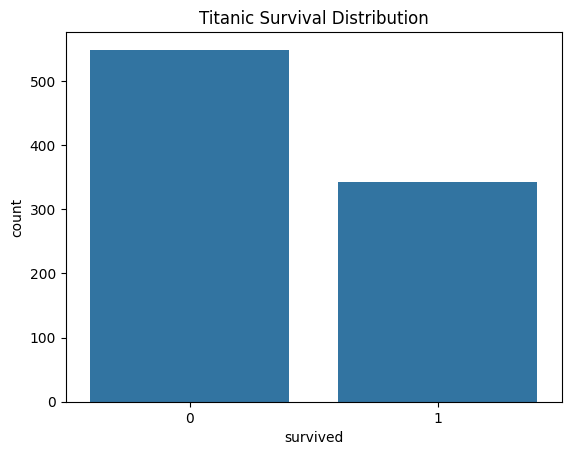

In [10]:
sns.countplot(x="survived", data=df)
plt.title("Titanic Survival Distribution")
plt.show()

## 5. Feature Engineering

In [12]:
df["FamilySize"] = df["sibsp"] + df["parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [14]:
df[["sibsp", "parch", "FamilySize", "IsAlone"]].head()

,sibsp,parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## 6. Select Features and Target

In [16]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "FamilySize",
    "IsAlone"
]

X = df[features]
y = df["survived"]

In [17]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 9)
Target shape: (891,)


## 7. Identify Numerical and Categorical Features

In [18]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare",
    "FamilySize",
    "IsAlone"
]

categorical_features = [
    "sex",
    "embarked"
]

## 8. Create Preprocessing Pipeline

In [19]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

## 9. Create Column Transformer

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 10. Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


## 11. Baseline Model — Decision Tree

In [23]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

In [24]:
decision_tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['pclass','sex','age',...,'embarked','FamilySize','IsAlone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [25]:
y_pred_dt = decision_tree.predict(X_test)

## 12. Evaluate Decision Tree

In [26]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("---------------------")
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Results
---------------------
Accuracy : 0.7654
Precision: 0.7547
Recall   : 0.5797
F1 Score : 0.6557


In [28]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



## 13. Confusion Matrix — Decision Tree

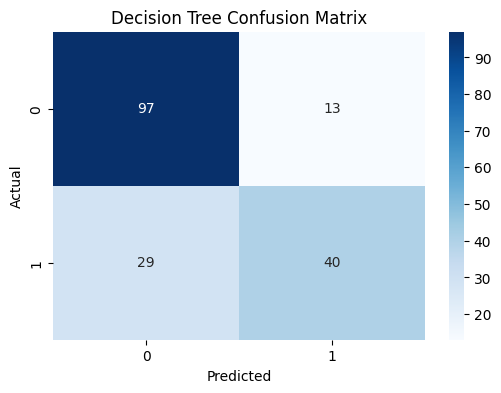

In [29]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 14. Random Forest Classifier

In [30]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [32]:
random_forest.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['pclass','sex','age',...,'embarked','FamilySize','IsAlone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [33]:
y_pred_rf = random_forest.predict(X_test)

## 15. Evaluate Random Forest

In [34]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy : 0.8101
Precision: 0.7397
Recall   : 0.7826
F1 Score : 0.7606


In [35]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84       110
           1       0.74      0.78      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## 16. Confusion Matrix — Random Forest

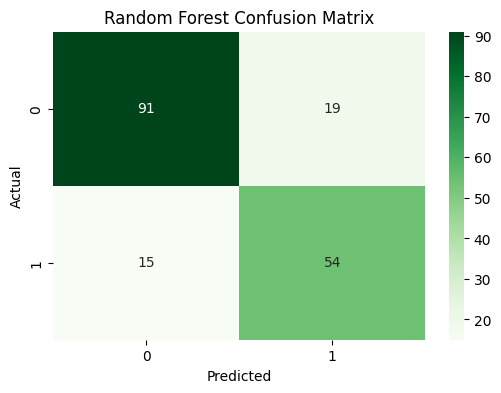

In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 17. XGBoost Classifier

In [37]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [38]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['pclass','sex','age',...,'embarked','FamilySize','IsAlone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

In [39]:
y_pred_xgb = xgb_model.predict(X_test)

## 18. Evaluate XGBoost

In [40]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

XGBoost Results
----------------
Accuracy : 0.7933
Precision: 0.7857
Recall   : 0.6377
F1 Score : 0.7040


In [41]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179



## 19. Confusion Matrix — XGBoost

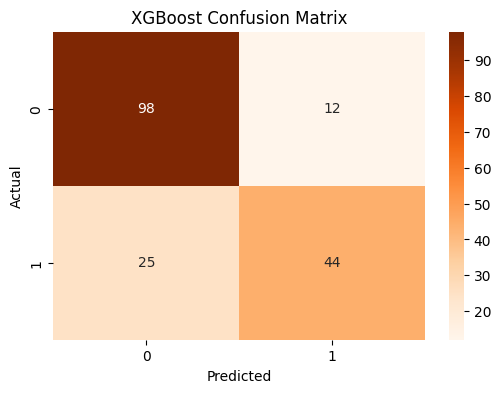

In [42]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 20. Compare All Models

In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.765363,0.754717,0.579710,0.655738
1,Random Forest,0.810056,0.739726,0.782609,0.760563
2,XGBoost,0.793296,0.785714,0.637681,0.704000


## 21. Visual Model Comparison

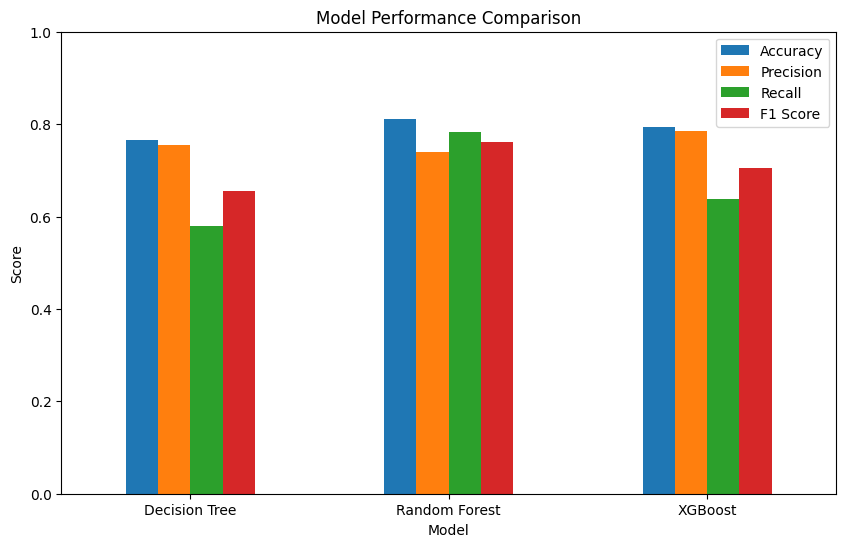

In [45]:
comparison_plot = comparison.set_index("Model")

comparison_plot[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## 22. Extract Feature Names

In [46]:
feature_names = random_forest.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare',
       'num__FamilySize', 'num__IsAlone', 'cat__sex_female',
       'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q',
       'cat__embarked_S'], dtype=object)

## 23. Random Forest Feature Importance

In [47]:
rf_classifier = random_forest.named_steps["classifier"]

In [48]:
rf_importance = rf_classifier.feature_importances_

In [49]:
rf_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
})

rf_features = rf_features.sort_values(
    by="Importance",
    ascending=False
)

rf_features.head(10)

,Feature,Importance
4,num__fare,0.258133
1,num__age,0.243246
8,cat__sex_male,0.144726
7,cat__sex_female,0.130984
0,num__pclass,0.079182
5,num__FamilySize,0.048318
2,num__sibsp,0.027074
3,num__parch,0.022952
11,cat__embarked_S,0.015177
9,cat__embarked_C,0.011904


## 24. Plot Random Forest Feature Importance

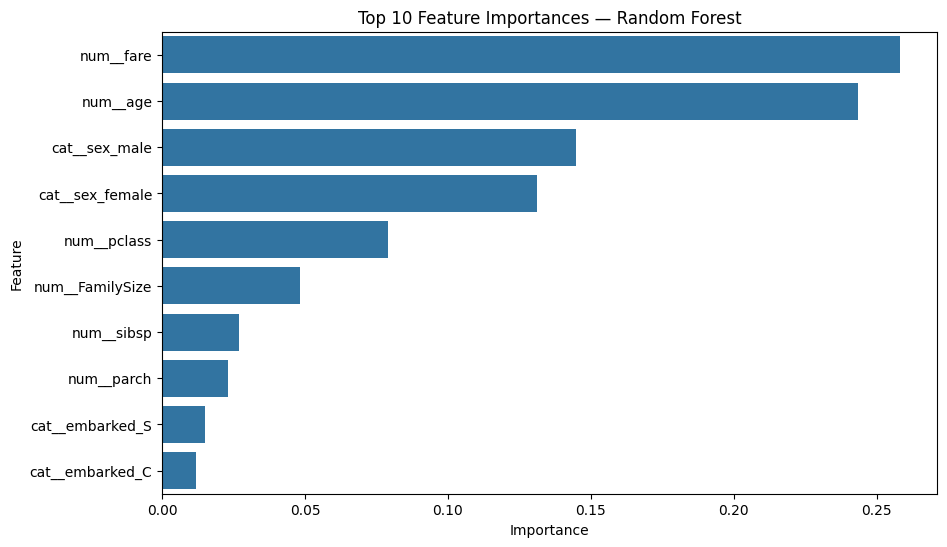

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_features.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 25. XGBoost Feature Importance

In [54]:
xgb_classifier = xgb_model.named_steps["classifier"]

In [58]:
xgb_importance = xgb_classifier.feature_importances_

In [59]:
xgb_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
})

xgb_features = xgb_features.sort_values(
    by="Importance",
    ascending=False
)

xgb_features.head(10)

,Feature,Importance
7,cat__sex_female,0.329795
8,cat__sex_male,0.235812
0,num__pclass,0.120779
11,cat__embarked_S,0.047766
4,num__fare,0.042700
1,num__age,0.040582
5,num__FamilySize,0.040503
2,num__sibsp,0.034965
10,cat__embarked_Q,0.029962
9,cat__embarked_C,0.027851


## 26. Plot XGBoost Feature Importance

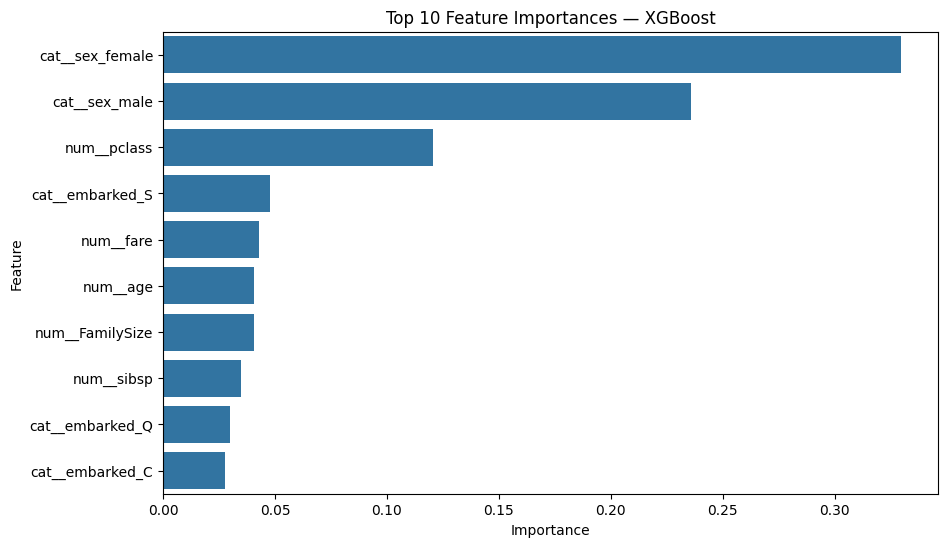

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_features.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 27. Compare Feature Importances

In [61]:
top_rf = rf_features.head(10)[
    ["Feature", "Importance"]
].copy()

top_xgb = xgb_features.head(10)[
    ["Feature", "Importance"]
].copy()

top_rf

,Feature,Importance
4,num__fare,0.258133
1,num__age,0.243246
8,cat__sex_male,0.144726
7,cat__sex_female,0.130984
0,num__pclass,0.079182
5,num__FamilySize,0.048318
2,num__sibsp,0.027074
3,num__parch,0.022952
11,cat__embarked_S,0.015177
9,cat__embarked_C,0.011904


In [62]:
top_xgb

,Feature,Importance
7,cat__sex_female,0.329795
8,cat__sex_male,0.235812
0,num__pclass,0.120779
11,cat__embarked_S,0.047766
4,num__fare,0.042700
1,num__age,0.040582
5,num__FamilySize,0.040503
2,num__sibsp,0.034965
10,cat__embarked_Q,0.029962
9,cat__embarked_C,0.027851


## 28. Combined Feature Importance Table

In [63]:
feature_comparison = pd.merge(
    top_rf,
    top_xgb,
    on="Feature",
    how="outer",
    suffixes=("_RandomForest", "_XGBoost")
)

feature_comparison = feature_comparison.fillna(0)

feature_comparison.sort_values(
    by="Importance_RandomForest",
    ascending=False
)

,Feature,Importance_RandomForest,Importance_XGBoost
7,num__fare,0.258133,0.042700
6,num__age,0.243246,0.040582
4,cat__sex_male,0.144726,0.235812
3,cat__sex_female,0.130984,0.329795
9,num__pclass,0.079182,0.120779
5,num__FamilySize,0.048318,0.040503
10,num__sibsp,0.027074,0.034965
8,num__parch,0.022952,0.000000
2,cat__embarked_S,0.015177,0.047766
0,cat__embarked_C,0.011904,0.027851


## 29. Random Forest vs XGBoost Explanation
Random Forest vs XGBoost

Random Forest builds multiple decision trees independently using random subsets of the training data and features, and combines their predictions through voting. XGBoost builds trees sequentially, where each new tree attempts to correct the errors made by previous trees. Random Forest mainly reduces variance and helps prevent overfitting, while XGBoost uses boosting to improve the model's predictive performance. Random Forest is generally easier to train and requires less tuning, while XGBoost can achieve excellent performance on structured/tabular datasets with proper tuning.

## 30. Feature Importance Explanation

Feature Importance Analysis

The feature importance plots show which features contribute most to the predictions of Random Forest and XGBoost. Both models may identify similar important features, such as passenger class, sex, age, and fare, but their rankings can differ because the models learn patterns differently. Comparing feature importance helps us understand which variables have the strongest influence on Titanic survival predictions.

## 31. Final Results

In [64]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Model Based on F1 Score:")
print(best_model)

Best Model Based on F1 Score:
Model        Random Forest
Accuracy          0.810056
Precision         0.739726
Recall            0.782609
F1 Score          0.760563
Name: 1, dtype: object


## 32. Final Conclusion

Conclusion

In this experiment, Decision Tree, Random Forest, and XGBoost were trained on the Titanic dataset. The two ensemble models generally provided more robust predictions than a single Decision Tree because they combine multiple decision trees. Random Forest builds trees independently and combines their predictions, whereas XGBoost builds trees sequentially to correct previous errors. Based on the evaluation metrics, the model with the highest F1 score can be considered the best-performing model for this experiment

## 33. Save the Comparison Table

In [65]:
comparison.round(4).to_csv(
    "model_comparison.csv",
    index=False
)

## 34. Save Feature Importance Tables

In [66]:
rf_features.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

xgb_features.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)